In [ ]:
# Import libraries and load the data
import pandas as pd
patients = pd.read_csv("../data/mimic-iv-3.1/hosp/patients.csv.gz")
admissions = pd.read_csv("../data/mimic-iv-3.1/hosp/admissions.csv.gz")
icustays = pd.read_csv("../data/mimic-iv-3.1/icu/icustays.csv.gz")
df = (
    icustays
    .merge(admissions, on = ["subject_id", "hadm_id"])
    .merge(patients, on ="subject_id")
)
df["mortality"] = df["hospital_expire_flag"]

In [52]:
# creating baseline features
df["age"] = df["anchor_age"]
df["gender"] = df["gender"].map({"M": 1, "F": 0})
df["los"] = df["los"]

In [53]:
# feature selection
include_los = False  # Keep False for admission-time prediction to avoid temporal leakage.

features = ["age", "gender"]
if include_los:
    features.append("los")

X = df[features]
y = df["mortality"]
X.head()

,age,gender
0,52,0
1,86,0
2,73,0
3,55,0
4,55,0


In [54]:
# check missing values in baseline features
print(X.isnull().sum())

age       0
gender    0
dtype: int64


In [55]:
# no global fill here; imputation is handled inside the model pipeline
print("Missing values before split:")
print(X.isnull().sum())

Missing values before split:
age       0
gender    0
dtype: int64


In [56]:
# patient-grouped train-test split (prevents same-patient leakage)
from sklearn.model_selection import GroupShuffleSplit

groups = df.loc[X.index, "subject_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

In [57]:
# train baseline model with leakage-safe preprocessing
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", GradientBoostingClassifier(random_state=42)),
    ]
)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

In [58]:
# evaluate the model
from sklearn.metrics import average_precision_score, roc_auc_score

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_pred)

print("Baseline ROC-AUC:", round(auc, 4))
print("Baseline PR-AUC:", round(pr_auc, 4))

Baseline ROC-AUC: 0.6061
Baseline PR-AUC: 0.1636


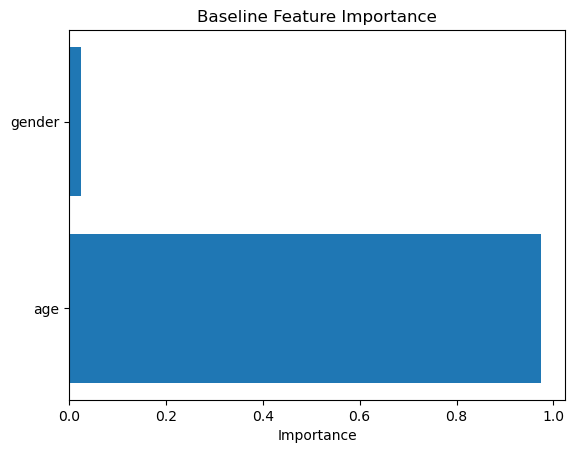

In [59]:
# feature importance
import matplotlib.pyplot as plt

importance = model.named_steps["clf"].feature_importances_
plt.barh(features, importance)
plt.title("Baseline Feature Importance")
plt.xlabel("Importance")
plt.show()

In [60]:
# loading processed ICU features
df_vital = pd.read_csv("../data/processed/icu_features.csv")

In [61]:
#checking columns name 
df_vital.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'heart_rate_x', 'sbp_x', 'dbp_x',
       'mbp_x', 'resp_rate_x', 'spo2_x', 'temperature_x', 'heart_rate_y',
       'sbp_y', 'dbp_y', 'mbp_y', 'resp_rate_y', 'spo2_y', 'temperature_y',
       'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'spo2', 'temperature',
       'age', 'gender', 'los', 'mortality'],
      dtype='str')

In [62]:
# normalize possible duplicated column names in processed data
rename_map = {
    "heart_rate_x": "heart_rate",
    "sbp_x": "sbp",
    "dbp_x": "dbp",
    "mbp_x": "mbp",
    "resp_rate_x": "resp_rate",
    "spo2_x": "spo2",
    "temperature_x": "temperature",
}

# rename only when canonical name is not already present
rename_candidates = {
    src: dst
    for src, dst in rename_map.items()
    if src in df_vital.columns and dst not in df_vital.columns
}
df_vital = df_vital.rename(columns=rename_candidates)

# keep first occurrence if any duplicate names still exist
df_vital = df_vital.loc[:, ~df_vital.columns.duplicated(keep="first")].copy()

In [63]:
df_vital.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'heart_rate_x', 'sbp_x', 'dbp_x',
       'mbp_x', 'resp_rate_x', 'spo2_x', 'temperature_x', 'heart_rate_y',
       'sbp_y', 'dbp_y', 'mbp_y', 'resp_rate_y', 'spo2_y', 'temperature_y',
       'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'spo2', 'temperature',
       'age', 'gender', 'los', 'mortality'],
      dtype='str')

In [64]:
# define features and target from processed ICU dataframe
include_los_vitals = False  # Keep False for admission-time prediction to avoid temporal leakage.

features_vital = [
    "age",
    "gender",
    "heart_rate",
    "sbp",
    "dbp",
    "mbp",
    "resp_rate",
    "spo2",
    "temperature",
]
if include_los_vitals:
    features_vital.append("los")

missing_features = [c for c in features_vital if c not in df_vital.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns: {missing_features}")

target_col = "mortality" if "mortality" in df_vital.columns else "hospital_expire_flag"
if target_col not in df_vital.columns:
    raise ValueError("Target column not found. Expected 'mortality' or 'hospital_expire_flag'.")

X_vital = df_vital[features_vital]
y_vital = df_vital[target_col]

In [65]:
# check missing values (imputation is handled inside the pipeline)
print(X_vital.isnull().sum())

age            0
gender         0
heart_rate     0
sbp            0
dbp            0
mbp            0
resp_rate      0
spo2           0
temperature    0
dtype: int64


In [66]:
# patient-grouped train-test split
from sklearn.model_selection import GroupShuffleSplit

groups_vital = df_vital.loc[X_vital.index, "subject_id"]
gss_vital = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_v, test_idx_v = next(gss_vital.split(X_vital, y_vital, groups=groups_vital))

X_train_v, X_test_v = X_vital.iloc[train_idx_v].copy(), X_vital.iloc[test_idx_v].copy()
y_train_v, y_test_v = y_vital.iloc[train_idx_v].copy(), y_vital.iloc[test_idx_v].copy()

In [67]:
# train Gradient Boosting model on vitals with leakage-safe preprocessing
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

model_v = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", GradientBoostingClassifier(random_state=42)),
    ]
)

model_v.fit(X_train_v, y_train_v)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

In [68]:
# predicted probabilities
pred_v = model_v.predict_proba(X_test_v)[:, 1]
print("Predictions shape:", pred_v.shape)

Predictions shape: (419,)


In [69]:
# evaluate model performance using AUC metrics
from sklearn.metrics import average_precision_score, roc_auc_score

pred_v = model_v.predict_proba(X_test_v)[:, 1]
roc_auc_v = roc_auc_score(y_test_v, pred_v)
pr_auc_v = average_precision_score(y_test_v, pred_v)

print("Vitals ROC-AUC:", round(roc_auc_v, 4))
print("Vitals PR-AUC:", round(pr_auc_v, 4))

Vitals ROC-AUC: 0.7564
Vitals PR-AUC: 0.397


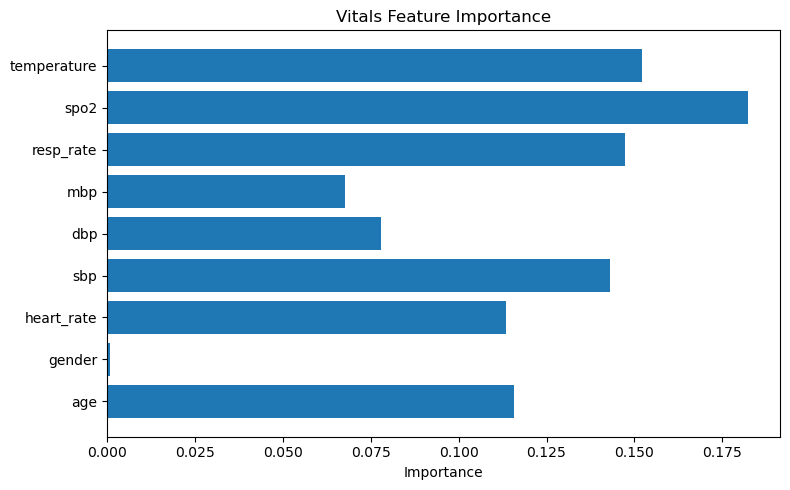

In [70]:
# plotting feature importance
import matplotlib.pyplot as plt

importance_v = model_v.named_steps["clf"].feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features_vital, importance_v)
plt.title("Vitals Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [71]:
#save the model
import joblib
joblib.dump(model_v, "../models/gb_model.pkl")

['../models/gb_model.pkl']

In [72]:
#choose threshold on grouped validation split and report holdout performance
import numpy as np
from sklearn.base import clone
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score

groups_train_v = df_vital.loc[X_train_v.index, "subject_id"]
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
subtrain_idx, val_idx = next(gss_inner.split(X_train_v, y_train_v, groups=groups_train_v))

X_subtrain = X_train_v.iloc[subtrain_idx]
y_subtrain = y_train_v.iloc[subtrain_idx]
X_val = X_train_v.iloc[val_idx]
y_val = y_train_v.iloc[val_idx]

model_v_threshold = clone(model_v)
model_v_threshold.fit(X_subtrain, y_subtrain)
val_scores = model_v_threshold.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_scores)
if len(thresholds) == 0:
    best_threshold = 0.5
else:
    f1_vals = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
    best_threshold = float(thresholds[np.nanargmax(f1_vals)])

test_preds_best = (pred_v >= best_threshold).astype(int)
test_f1 = f1_score(y_test_v, test_preds_best)
test_precision = precision_score(y_test_v, test_preds_best, zero_division=0)
test_recall = recall_score(y_test_v, test_preds_best, zero_division=0)

print("Threshold tuning (vitals model)")
print(f"  Selected threshold from grouped validation: {best_threshold:.4f}")
print(f"  Test precision @ threshold: {test_precision:.4f}")
print(f"  Test recall @ threshold: {test_recall:.4f}")
print(f"  Test F1 @ threshold: {test_f1:.4f}")

Threshold tuning (vitals model)
  Selected threshold from grouped validation: 0.3536
  Test precision @ threshold: 0.3667
  Test recall @ threshold: 0.1897
  Test F1 @ threshold: 0.2500


In [73]:
# Bootstrap confidence intervals for discrimination metrics
import numpy as np
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

def bootstrap_ci_binary(y_true, y_score, metric_fn, n_boot=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        s_b = y_score[idx]
        if len(np.unique(y_b)) < 2:
            continue
        vals.append(metric_fn(y_b, s_b))
    if not vals:
        return (float("nan"), float("nan"), float("nan"))
    vals = np.sort(np.asarray(vals))
    lo = float(np.quantile(vals, alpha / 2))
    md = float(np.quantile(vals, 0.5))
    hi = float(np.quantile(vals, 1 - alpha / 2))
    return (lo, md, hi)

# Baseline model test predictions
y_pred_base = model.predict_proba(X_test)[:, 1]
base_auc_ci = bootstrap_ci_binary(y_test.to_numpy(), y_pred_base, roc_auc_score)
base_pr_ci = bootstrap_ci_binary(y_test.to_numpy(), y_pred_base, average_precision_score)

# Vitals model test predictions
pred_v = model_v.predict_proba(X_test_v)[:, 1]
vital_auc_ci = bootstrap_ci_binary(y_test_v.to_numpy(), pred_v, roc_auc_score)
vital_pr_ci = bootstrap_ci_binary(y_test_v.to_numpy(), pred_v, average_precision_score)

print("Baseline test metrics")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_base):.4f} (95% CI {base_auc_ci[0]:.4f}, {base_auc_ci[2]:.4f})")
print(f"  PR-AUC : {average_precision_score(y_test, y_pred_base):.4f} (95% CI {base_pr_ci[0]:.4f}, {base_pr_ci[2]:.4f})")
print(f"  Brier  : {brier_score_loss(y_test, y_pred_base):.4f}")

print("Vitals test metrics")
print(f"  ROC-AUC: {roc_auc_score(y_test_v, pred_v):.4f} (95% CI {vital_auc_ci[0]:.4f}, {vital_auc_ci[2]:.4f})")
print(f"  PR-AUC : {average_precision_score(y_test_v, pred_v):.4f} (95% CI {vital_pr_ci[0]:.4f}, {vital_pr_ci[2]:.4f})")
print(f"  Brier  : {brier_score_loss(y_test_v, pred_v):.4f}")

Baseline test metrics
  ROC-AUC: 0.6061 (95% CI 0.5947, 0.6190)
  PR-AUC : 0.1636 (95% CI 0.1546, 0.1747)
  Brier  : 0.1029
Vitals test metrics
  ROC-AUC: 0.7564 (95% CI 0.6917, 0.8228)
  PR-AUC : 0.3970 (95% CI 0.2850, 0.5216)
  Brier  : 0.1082


In [74]:
# split integrity and class-balance diagnostics
baseline_train_subjects = set(df.loc[X_train.index, "subject_id"])
baseline_test_subjects = set(df.loc[X_test.index, "subject_id"])
baseline_overlap = baseline_train_subjects & baseline_test_subjects
assert len(baseline_overlap) == 0, "Leakage risk: baseline split has overlapping subjects."

vital_train_subjects = set(df_vital.loc[X_train_v.index, "subject_id"])
vital_test_subjects = set(df_vital.loc[X_test_v.index, "subject_id"])
vital_overlap = vital_train_subjects & vital_test_subjects
assert len(vital_overlap) == 0, "Leakage risk: vitals split has overlapping subjects."

print("Baseline split diagnostics")
print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"  Mortality rate train: {y_train.mean():.4f}, test: {y_test.mean():.4f}")
print(f"  Subject overlap count: {len(baseline_overlap)}")

print("Vitals split diagnostics")
print(f"  Train size: {len(X_train_v)}, Test size: {len(X_test_v)}")
print(f"  Mortality rate train: {y_train_v.mean():.4f}, test: {y_test_v.mean():.4f}")
print(f"  Subject overlap count: {len(vital_overlap)}")

Baseline split diagnostics
  Train size: 75502, Test size: 18956
  Mortality rate train: 0.1206, test: 0.1185
  Subject overlap count: 0
Vitals split diagnostics
  Train size: 1685, Test size: 419
  Mortality rate train: 0.1264, test: 0.1384
  Subject overlap count: 0


In [75]:
# grouped cross-validation for stability estimates
from sklearn.base import clone
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
groups_cv = df_vital.loc[X_vital.index, "subject_id"]

cv_rows = []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_vital, y_vital, groups=groups_cv), start=1):
    X_tr, X_te = X_vital.iloc[tr_idx], X_vital.iloc[te_idx]
    y_tr, y_te = y_vital.iloc[tr_idx], y_vital.iloc[te_idx]

    fold_model = clone(model_v)
    fold_model.fit(X_tr, y_tr)
    y_score = fold_model.predict_proba(X_te)[:, 1]

    cv_rows.append(
        {
            "fold": fold,
            "n_train": int(len(tr_idx)),
            "n_test": int(len(te_idx)),
            "mortality_rate_test": float(y_te.mean()),
            "roc_auc": float(roc_auc_score(y_te, y_score)),
            "pr_auc": float(average_precision_score(y_te, y_score)),
            "brier": float(brier_score_loss(y_te, y_score)),
        }
    )

cv_results = pd.DataFrame(cv_rows)
print("Grouped 5-fold CV results (vitals model)")
print(cv_results.to_string(index=False))

print("\nGrouped CV summary (mean +/- std)")
print(f"ROC-AUC: {cv_results['roc_auc'].mean():.4f} +/- {cv_results['roc_auc'].std(ddof=1):.4f}")
print(f"PR-AUC : {cv_results['pr_auc'].mean():.4f} +/- {cv_results['pr_auc'].std(ddof=1):.4f}")
print(f"Brier  : {cv_results['brier'].mean():.4f} +/- {cv_results['brier'].std(ddof=1):.4f}")

Grouped 5-fold CV results (vitals model)
 fold  n_train  n_test  mortality_rate_test  roc_auc   pr_auc    brier
    1     1683     421             0.111639 0.765901 0.378110 0.089260
    2     1683     421             0.161520 0.794034 0.501398 0.111328
    3     1683     421             0.114014 0.806747 0.465843 0.081762
    4     1683     421             0.125891 0.755281 0.336583 0.102246
    5     1684     420             0.130952 0.803014 0.511852 0.088134

Grouped CV summary (mean +/- std)
ROC-AUC: 0.7850 +/- 0.0231
PR-AUC : 0.4388 +/- 0.0776
Brier  : 0.0945 +/- 0.0120
